# 184. Department Highest Salary
https://leetcode.com/problems/department-highest-salary/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| JOIN + Subquery MAX | O(n + m) | O(n) | Group max per department |
| RANK() Window Function | O(n log n) | O(n) | Rank within department |
| IN with tuple comparison | O(n + m) | O(n) | Tuple-based filter |

## Methodology

This is a SQL problem. Find employees with the highest salary in each department.
Multiple employees can share the highest salary. We join Employee with Department,
then filter using a subquery that finds the MAX salary per departmentId.

## Solutions

### C#

In [ ]:
// SQL Problem - Department Highest Salary
// SQL Solution:
//
// SELECT d.name AS Department, e.name AS Employee, e.salary AS Salary
// FROM Employee e
// JOIN Department d ON e.departmentId = d.id
// WHERE (e.departmentId, e.salary) IN (
//     SELECT departmentId, MAX(salary)
//     FROM Employee
//     GROUP BY departmentId
// );

// C# programmatic equivalent
using System;
using System.Linq;
using System.Collections.Generic;

public class Employee { public string Name; public int Salary; public int DeptId; }
public class Department { public int Id; public string Name; }

public class Solution
{
    public static List<(string dept, string emp, int salary)> DeptHighestSalary(
        List<Employee> employees, List<Department> departments)
    {
        var deptMap = departments.ToDictionary(d => d.Id, d => d.Name);
        var maxPerDept = employees.GroupBy(e => e.DeptId)
                                  .ToDictionary(g => g.Key, g => g.Max(e => e.Salary));
        return employees
            .Where(e => maxPerDept.ContainsKey(e.DeptId) && e.Salary == maxPerDept[e.DeptId])
            .Select(e => (deptMap[e.DeptId], e.Name, e.Salary))
            .ToList();
    }
}

// Test
var emps = new List<Employee>
{
    new Employee { Name = "Joe", Salary = 70000, DeptId = 1 },
    new Employee { Name = "Jim", Salary = 90000, DeptId = 1 },
    new Employee { Name = "Henry", Salary = 80000, DeptId = 2 }
};
var depts = new List<Department>
{
    new Department { Id = 1, Name = "IT" },
    new Department { Id = 2, Name = "Sales" }
};
foreach (var r in Solution.DeptHighestSalary(emps, depts))
    Console.WriteLine($"{r.dept}: {r.emp} ({r.salary})");

### Python

In [ ]:
// SQL Problem - Python programmatic equivalent
//
// from collections import defaultdict
//
// def dept_highest_salary(employees, departments):
//     dept_map = {d['id']: d['name'] for d in departments}
//     max_sal = defaultdict(int)
//     for e in employees:
//         max_sal[e['deptId']] = max(max_sal[e['deptId']], e['salary'])
//     return [
//         (dept_map[e['deptId']], e['name'], e['salary'])
//         for e in employees
//         if e['salary'] == max_sal[e['deptId']]
//     ]

### Go

In [ ]:
// SQL Problem - Go programmatic equivalent
//
// type Employee struct { Name string; Salary int; DeptID int }
// type Department struct { ID int; Name string }
// type Result struct { Dept, Emp string; Salary int }
//
// func deptHighestSalary(employees []Employee, departments []Department) []Result {
//     deptMap := make(map[int]string)
//     for _, d := range departments { deptMap[d.ID] = d.Name }
//     maxSal := make(map[int]int)
//     for _, e := range employees {
//         if e.Salary > maxSal[e.DeptID] { maxSal[e.DeptID] = e.Salary }
//     }
//     var result []Result
//     for _, e := range employees {
//         if e.Salary == maxSal[e.DeptID] {
//             result = append(result, Result{deptMap[e.DeptID], e.Name, e.Salary})
//         }
//     }
//     return result
// }

### Rust

In [ ]:
// SQL Problem - Rust programmatic equivalent
//
// use std::collections::HashMap;
//
// struct Employee { name: String, salary: i32, dept_id: i32 }
// struct Department { id: i32, name: String }
//
// fn dept_highest_salary(
//     employees: &[Employee],
//     departments: &[Department],
// ) -> Vec<(String, String, i32)> {
//     let dept_map: HashMap<i32, &str> =
//         departments.iter().map(|d| (d.id, d.name.as_str())).collect();
//     let mut max_sal: HashMap<i32, i32> = HashMap::new();
//     for e in employees {
//         let entry = max_sal.entry(e.dept_id).or_insert(0);
//         *entry = (*entry).max(e.salary);
//     }
//     employees.iter()
//         .filter(|e| max_sal.get(&e.dept_id) == Some(&e.salary))
//         .map(|e| (dept_map[&e.dept_id].to_string(), e.name.clone(), e.salary))
//         .collect()
// }

## Example Scenarios

### 1. Common Case — One Top Earner Per Department

**Input:** Employee: `{('Joe',70000,1), ('Jim',90000,1), ('Henry',80000,2)}`, Department: `{(1,'IT'), (2,'Sales')}`

Subquery finds MAX(salary) per dept: IT=90k, Sales=80k. Filter employees matching their dept's max: Jim (90k in IT) and Henry (80k in Sales). Joe (70k) is excluded.

**WHY it's useful:** Standard JOIN + subquery MAX pattern. Time: $O(n + m)$ with hash aggregation. One pass for MAX, one pass to filter.

---

### 2. Slightly Complex — Tied Highest Salaries

**Input:** Employee: `{('Alice',95000,1), ('Bob',95000,1), ('Carol',80000,1), ('Dave',70000,2)}`

IT's MAX = 95k. Both Alice and Bob match. Carol (80k) does not. Using `= MAX(salary)` correctly returns both tied employees. A `LIMIT 1` approach would miss one.

**WHY it's tricky:** Ties at the top must return all tied employees. The equality check against MAX handles this naturally, but `ROW_NUMBER()` (which breaks ties arbitrarily) would not.

---

### 3. Edge Case: Time Factor — Many Departments ($d = 10{,}000$)

**Input:** $n = 100{,}000$ employees across $d = 10{,}000$ departments (10 per dept). Each dept has salaries \$10 through \$100.

GROUP BY departmentId computes MAX in $O(n)$. Hash join with the max-salary subquery: $O(n + d)$. A correlated subquery approach would be $O(n \times d)$.

**WHY it tests time:** With 10,000 departments, hash aggregation stays $O(n)$ while a correlated subquery scanning each department per row becomes $O(n \times n/d)$.

---

### 4. Edge Case: Space Factor — All Same Salary, One Department

**Input:** $n = 100{,}000$ employees, all in dept 1, all salary = \$50,000.

MAX(salary) = 50,000. Every employee matches. Result set contains all 100,000 rows. The MAX subquery result is tiny ($O(1)$) but the output dominates at $O(n)$.

**WHY it tests space:** Maximum result size — every row qualifies. Output alone requires $O(n)$ memory. Cannot reduce without changing the problem.

---

### 5. Almost-Impossible — INT_MAX and Zero Salary Boundaries

**Input:** `{('Alpha',2147483647,1), ('Beta',2147483647,1), ('Gamma',2147483646,1), ('Delta',0,2), ('Eps',0,2)}`

Dept 1 MAX = $2^{31}-1$ (INT_MAX). Alpha and Beta both match. Gamma ($2^{31}-2$) is excluded by just \$1. Dept 2 MAX = 0. Both Delta and Eps match at \$0 salary.

**WHY it's extreme:** Salary at INT_MAX boundary — `MAX()` aggregation must handle without overflow. \$0 salary is valid and matches correctly. Testing both extremes simultaneously catches boundary arithmetic issues.

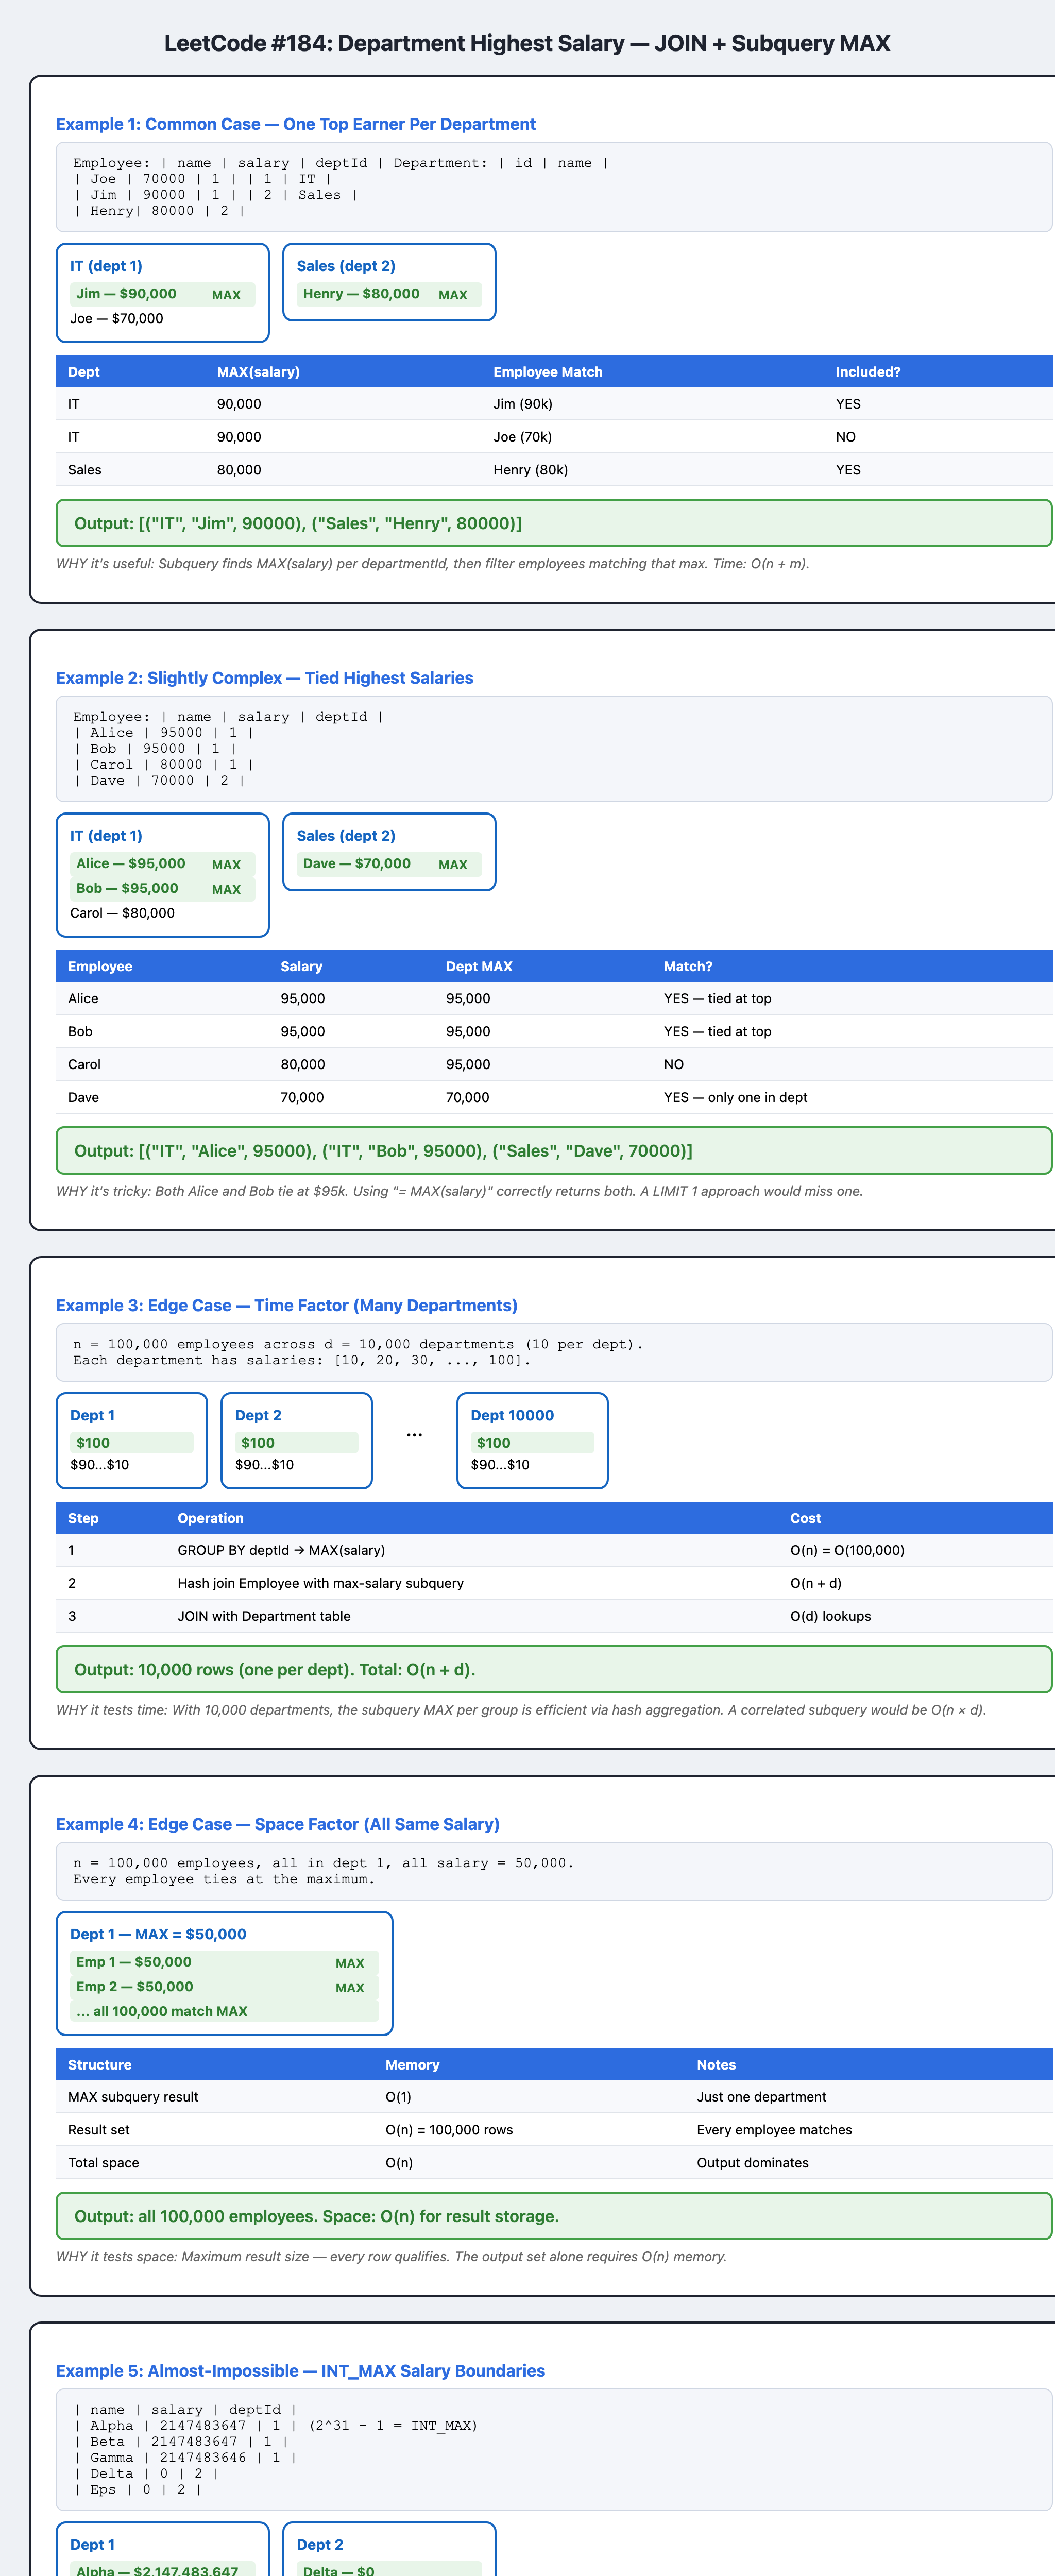